# Задание 1 — Аналитика добычи нефти



In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'psycopg2-binary', 'boto3', 'pyarrow', 's3fs', '--quiet'], check=True)
print('Dependencies ready ')

Dependencies ready 


In [2]:
import os, io, warnings
import boto3
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sqlalchemy import create_engine

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

PG_URI = (
    f"postgresql+psycopg2://"
    f"{os.getenv('PG_USER','oilfield')}:{os.getenv('PG_PASSWORD','oilfield123')}"
    f"@{os.getenv('PG_HOST','postgres')}:{os.getenv('PG_PORT','5432')}"
    f"/{os.getenv('PG_DB','oilfield')}"
)
MINIO_ENDPOINT   = os.getenv('MINIO_ENDPOINT',   'http://minio:9000')
MINIO_ACCESS_KEY = os.getenv('MINIO_ACCESS_KEY', 'minioadmin')
MINIO_SECRET_KEY = os.getenv('MINIO_SECRET_KEY', 'minioadmin123')
BUCKET           = os.getenv('MINIO_BUCKET',     'oilfield')

engine = create_engine(PG_URI)

s3 = boto3.client(
    's3',
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
)

def read_parquet(bucket, prefix):
    resp = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
    frames = []
    for obj in resp.get('Contents', []):
        if obj['Key'].endswith('.parquet'):
            buf = io.BytesIO()
            s3.download_fileobj(bucket, obj['Key'], buf)
            buf.seek(0)
            frames.append(pq.read_table(buf).to_pandas())
    return pd.concat(frames, ignore_index=True)


## 1. Загрузка данных

In [3]:
prod_df  = read_parquet(BUCKET, 'production/')
wells_df = read_parquet(BUCKET, 'wells/')
tele_df  = read_parquet(BUCKET, 'telemetry/')

print(f'production:  {prod_df.shape}')
print(f'wells:       {wells_df.shape}')
print(f'telemetry:   {tele_df.shape}')

production:  (162000, 10)
wells:       (20, 9)
telemetry:   (2370, 11)


## 2. EDA — исследовательский анализ данных

In [4]:
print('=== production — первые строки ===')
display(prod_df.head())
print('\n=== Пропуски ===')
display(prod_df.isnull().sum())
print('\n=== Статистика ===')
display(prod_df.describe())

=== production — первые строки ===


,prod_id,well_id,prod_date,oil_rate_m3,water_cut,gas_rate_m3,downtime_hrs,year,month,week
0,1,1,2026-02-16,97.163,13.56,19.226,0.53,2026,2,8
1,2,2,2026-02-16,87.253,11.69,17.842,0.99,2026,2,8
2,3,3,2026-02-16,42.278,12.71,9.492,13.25,2026,2,8
3,4,4,2026-02-16,117.844,15.48,23.717,0.19,2026,2,8
4,5,5,2026-02-16,131.761,14.63,28.986,0.11,2026,2,8



=== Пропуски ===


prod_id         0
well_id         0
prod_date       0
oil_rate_m3     0
water_cut       0
gas_rate_m3     0
downtime_hrs    0
year            0
month           0
week            0
dtype: int64


=== Статистика ===


,prod_id,well_id,prod_date,oil_rate_m3,water_cut,gas_rate_m3,downtime_hrs,year,month,week
count,162000.000000,162000.000000,162000,162000.000000,162000.000000,162000.000000,162000.000000,162000.0,162000.000000,162000.000000
mean,81000.500000,10.500000,2026-04-01 12:00:00,64.773782,28.645224,13.250541,4.050412,2026.0,3.544444,13.933333
min,1.000000,1.000000,2026-02-16 00:00:00,13.089000,11.300000,2.000000,0.000000,2026.0,2.000000,8.000000
25%,40500.750000,5.750000,2026-03-10 00:00:00,42.232750,21.890000,8.196000,0.670000,2026.0,3.000000,11.000000
50%,81000.500000,10.500000,2026-04-01 12:00:00,63.328500,28.650000,12.505000,1.330000,2026.0,4.000000,14.000000
75%,121500.250000,15.250000,2026-04-24 00:00:00,85.723250,35.390000,17.669000,3.000000,2026.0,4.000000,17.000000
max,162000.000000,20.000000,2026-05-16 00:00:00,139.869000,45.990000,28.999000,20.000000,2026.0,5.000000,20.000000
std,46765.516142,5.766299,NaN,28.981802,8.122535,6.564047,5.678469,0.0,0.944709,3.708261


In [5]:
# Объединяем production + wells
prod_df['prod_date'] = pd.to_datetime(prod_df['prod_date'])
df = prod_df.merge(wells_df[['well_id','well_name','field','region','status']], on='well_id')
print(f'Объединённый датасет: {df.shape}')
display(df.head(3))

Объединённый датасет: (162000, 14)


,prod_id,well_id,prod_date,oil_rate_m3,water_cut,gas_rate_m3,downtime_hrs,year,month,week,well_name,field,region,status
0,1,1,2026-02-16,97.163,13.56,19.226,0.53,2026,2,8,Скв-101,Самотлорское,ХМАО,active
1,21,1,2026-02-17,98.614,17.45,19.893,0.86,2026,2,8,Скв-101,Самотлорское,ХМАО,active
2,41,1,2026-02-18,93.518,11.40,17.971,1.33,2026,2,8,Скв-101,Самотлорское,ХМАО,active


## 3. График 1 — Суточная добыча нефти

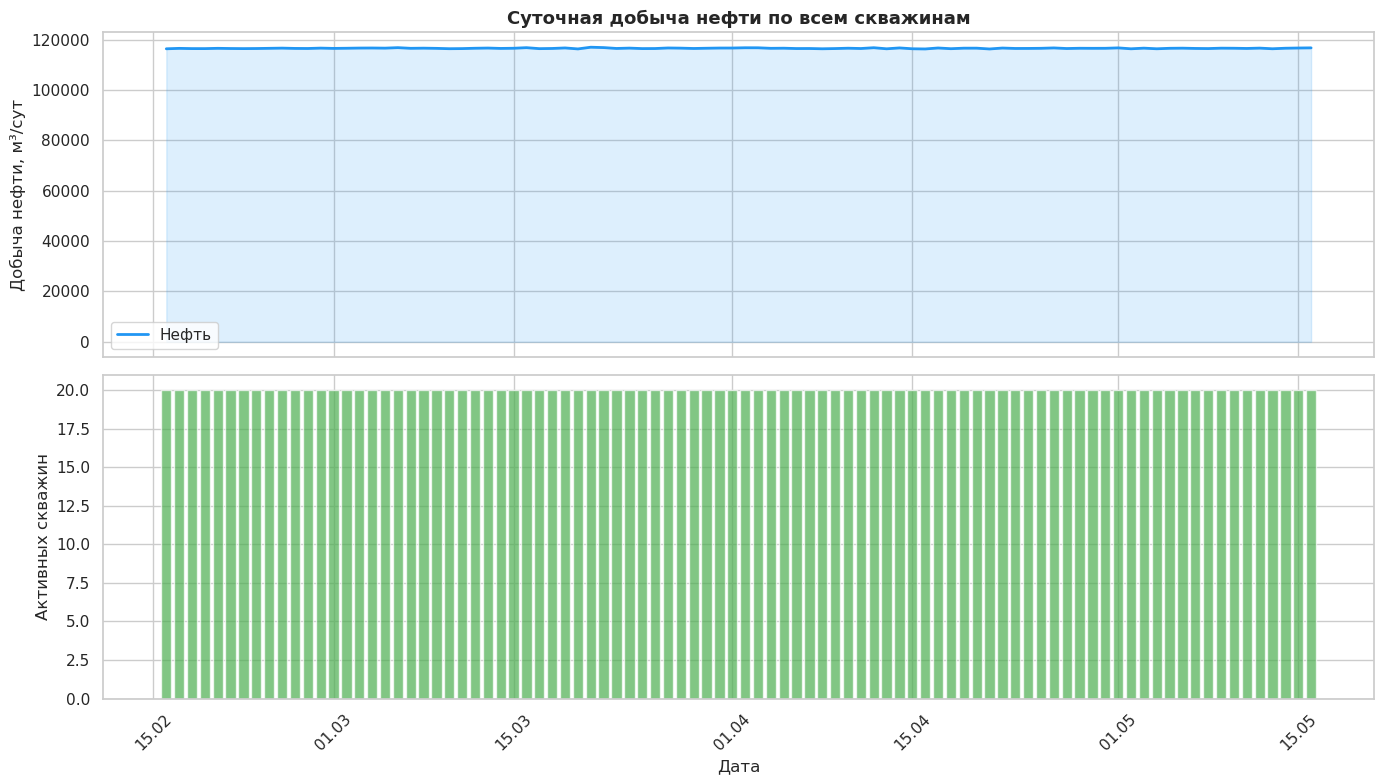

Chart 1 saved 


In [6]:
daily = (
    df.groupby('prod_date')
    .agg(total_oil=('oil_rate_m3','sum'),
         total_gas=('gas_rate_m3','sum'),
         active_wells=('well_id','nunique'))
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(daily['prod_date'], daily['total_oil'], color='#2196F3', linewidth=2, label='Нефть')
ax1.fill_between(daily['prod_date'], daily['total_oil'], alpha=0.15, color='#2196F3')
ax1.set_ylabel('Добыча нефти, м³/сут')
ax1.set_title('Суточная добыча нефти по всем скважинам', fontsize=13, fontweight='bold')
ax1.legend()

ax2.bar(daily['prod_date'], daily['active_wells'], color='#4CAF50', alpha=0.7, width=0.8)
ax2.set_ylabel('Активных скважин')
ax2.set_xlabel('Дата')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()
print('Chart 1 saved ')

## 4. KPI по скважинам

In [7]:
kpi = (
    df.groupby(['well_id','well_name','field','status'])
    .agg(
        avg_oil_rate   = ('oil_rate_m3',   'mean'),
        total_oil      = ('oil_rate_m3',   'sum'),
        avg_water_cut  = ('water_cut',     'mean'),
        total_downtime = ('downtime_hrs',  'sum'),
        days_count     = ('prod_date',     'count'),
    )
    .reset_index()
)
kpi['downtime_pct'] = (kpi['total_downtime'] / (kpi['days_count'] * 24) * 100).round(2)
kpi = kpi.sort_values('total_oil', ascending=False)
display(kpi[['well_name','field','avg_oil_rate','total_oil','downtime_pct','status']].head(10))

,well_name,field,avg_oil_rate,total_oil,downtime_pct,status
4,Скв-105,Приобское,123.012615,996402.183,4.15,active
3,Скв-104,Приобское,109.296528,885301.877,4.14,active
10,Скв-301,Юрубчено-Тохомское,100.225850,811829.384,4.16,active
11,Скв-302,Юрубчено-Тохомское,95.710738,775256.981,4.16,active
0,Скв-101,Самотлорское,86.553721,701085.142,4.15,active
8,Скв-203,Ванкорское,82.852003,671101.226,4.14,active
1,Скв-102,Самотлорское,80.204824,649659.072,4.13,active
7,Скв-202,Ванкорское,74.691834,605003.852,4.14,active
6,Скв-201,Ванкорское,71.049027,575497.121,4.19,active
13,Скв-402,Мессояхское,65.630626,531608.073,4.15,active


## 5. График 2 — Топ скважин по добыче

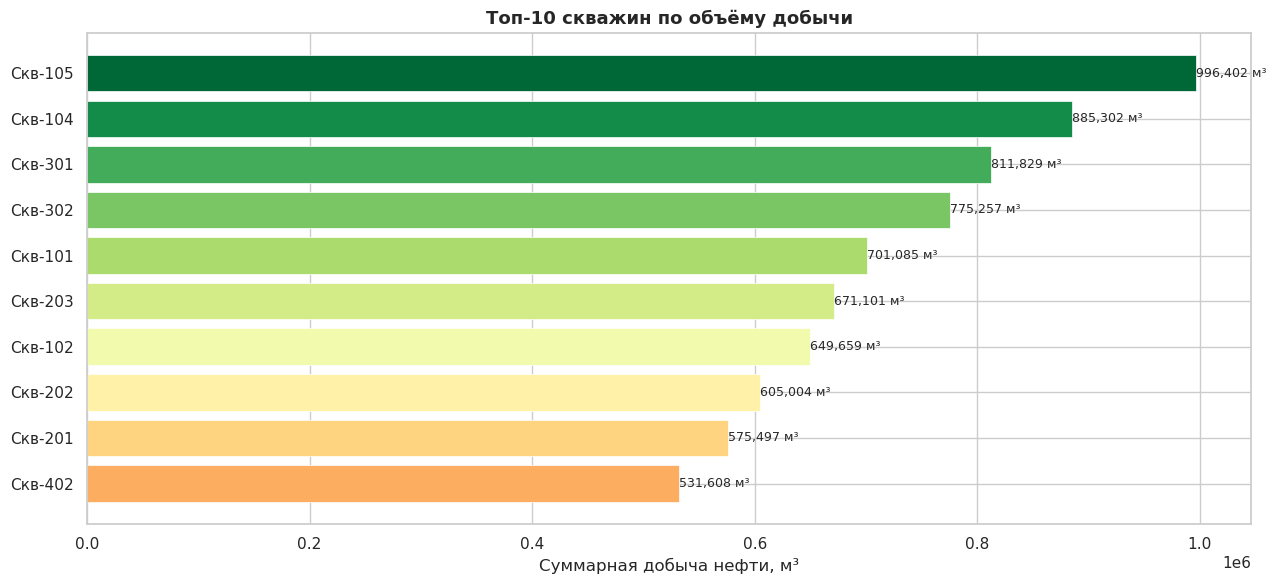

Chart 2 saved 


In [8]:
top10 = kpi.head(10)
colors = plt.cm.RdYlGn(np.linspace(0.3, 1.0, len(top10)))[::-1]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top10['well_name'], top10['total_oil'], color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top10['total_oil']):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} м³', va='center', fontsize=9)

ax.set_xlabel('Суммарная добыча нефти, м³')
ax.set_title('Топ-10 скважин по объёму добычи', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print('Chart 2 saved ')

## 6. График 3 — Heatmap: давление vs дебит

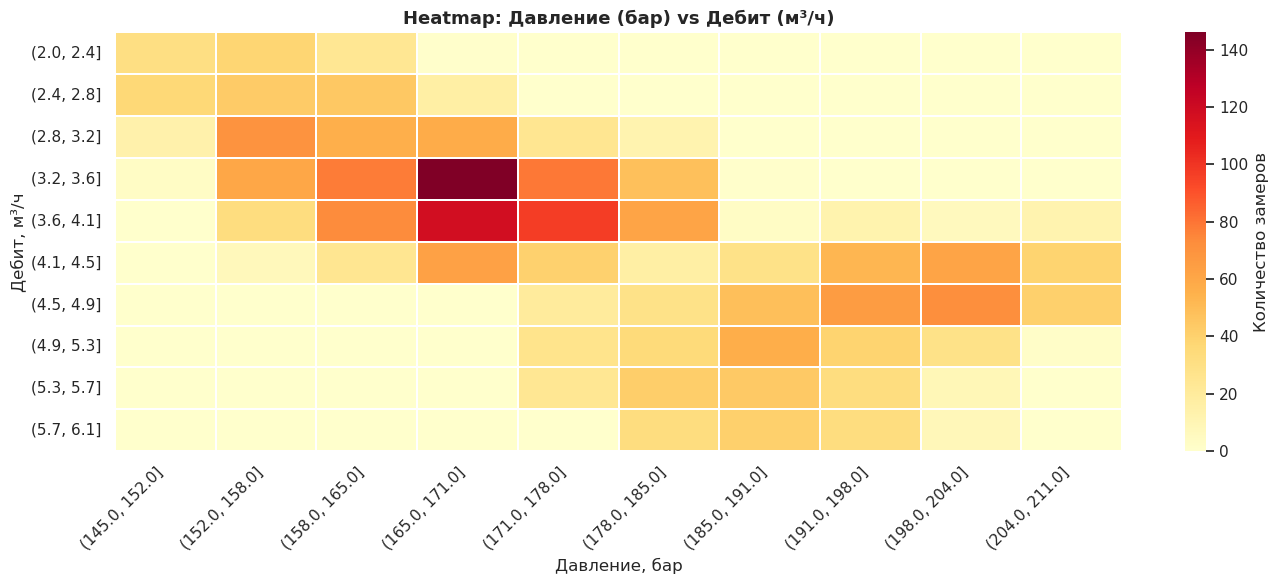

Chart 3 saved 


In [9]:
tele_df['recorded_at'] = pd.to_datetime(tele_df['recorded_at'])
tele_df = tele_df.dropna(subset=['pressure_bar','flow_rate_m3h'])

# Бинирование для heatmap
tele_df['p_bin']    = pd.cut(tele_df['pressure_bar'],   bins=10, precision=0)
tele_df['flow_bin'] = pd.cut(tele_df['flow_rate_m3h'],  bins=10, precision=1)

hm = tele_df.pivot_table(values='telem_id', index='flow_bin', columns='p_bin',
                          aggfunc='count', fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(hm, cmap='YlOrRd', linewidths=0.3, ax=ax, cbar_kws={'label': 'Количество замеров'})
ax.set_title('Heatmap: Давление (бар) vs Дебит (м³/ч)', fontsize=13, fontweight='bold')
ax.set_xlabel('Давление, бар')
ax.set_ylabel('Дебит, м³/ч')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('Chart 3 saved ')

## 7. Лучшие и худшие скважины

In [10]:
print(' Топ-5 скважин:')
display(kpi[['well_name','field','total_oil','avg_oil_rate','downtime_pct']].head(5))

print('\n  5 худших:')
display(kpi[['well_name','field','total_oil','avg_oil_rate','downtime_pct']].tail(5))

 Топ-5 скважин:


,well_name,field,total_oil,avg_oil_rate,downtime_pct
4,Скв-105,Приобское,996402.183,123.012615,4.15
3,Скв-104,Приобское,885301.877,109.296528,4.14
10,Скв-301,Юрубчено-Тохомское,811829.384,100.225850,4.16
11,Скв-302,Юрубчено-Тохомское,775256.981,95.710738,4.16
0,Скв-101,Самотлорское,701085.142,86.553721,4.15



  5 худших:


,well_name,field,total_oil,avg_oil_rate,downtime_pct
2,Скв-103,Самотлорское,331653.692,40.944900,66.82
9,Скв-204,Ванкорское,309883.190,38.257184,66.65
5,Скв-106,Приобское,221366.155,27.329155,37.46
14,Скв-403,Мессояхское,184482.833,22.775658,37.49
19,Скв-603,Бованенковское,162426.459,20.052649,66.70


## 8. Сохранение витрины в PostgreSQL

In [11]:
kpi.to_sql('analytics_well_kpi', engine, if_exists='replace', index=False)
print(f'Записано {len(kpi)} строк в таблицу analytics_well_kpi ')

daily.to_sql('analytics_daily_production', engine, if_exists='replace', index=False)
print(f'Записано {len(daily)} строк в таблицу analytics_daily_production ')

Записано 20 строк в таблицу analytics_well_kpi 
Записано 90 строк в таблицу analytics_daily_production 
